In [122]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

### GENERATE POSITION OF A STAR centered in gaussian
case with homoscedastic error $\sigma = 0.2$. 

In [125]:
N= 5
np.random.seed(42)
#pos_star =np.random.normal(loc=1, scale=0.2, size=N)
pos_star = norm.rvs(loc=1, scale=0.2, size=N)
#plt.hist(pos_star) #test hist for the distribution 

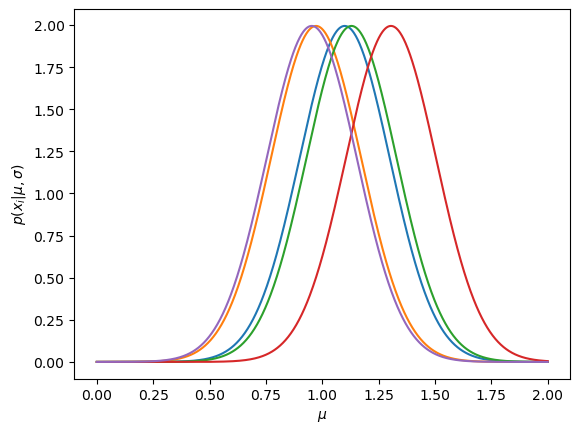

In [127]:
x = np.linspace(0, 2, 1000) #x axis

for pos in pos_star:
    pdf_gauss = norm.pdf(x, loc=pos, scale=0.2)
    plt.plot(x, pdf_gauss)
    plt.xlabel(r'$\mu$') 
    plt.ylabel(r'$p(x_i|\mu,\sigma)$')

In [129]:
pdf_gauss_tot = []

for pos in pos_star: 
    pdf_gauss = norm.pdf(x, loc=pos, scale=0.2)
    pdf_gauss_tot.append(pdf_gauss)

#print(pdf_gauss_tot)
like = np.prod(pdf_gauss_tot, axis=0)
#print(like)
ln_like = np.log(like) #log in base e 
#print(like)
#print(len(like))

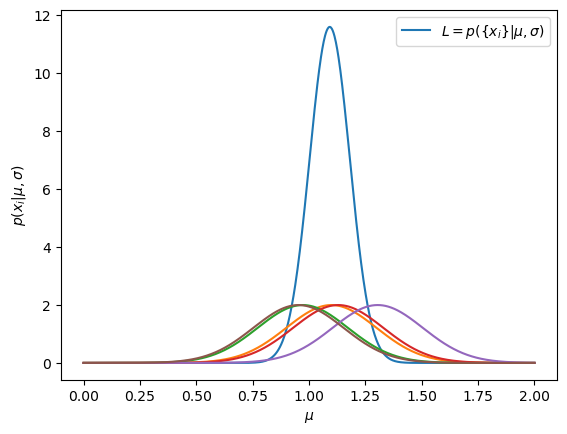

In [131]:
plt.plot(x, like, label=r"$L = p(\{x_i\}|\mu,\sigma)$")
for pos in pos_star: 
    pdf_gauss = norm.pdf(x, loc=pos, scale=0.2)
    plt.plot(x, pdf_gauss)
    plt.xlabel(r'$\mu$') 
    plt.ylabel(r'$p(x_i|\mu,\sigma)$')

plt.legend()

In [133]:
#print(np.argsort(like))
arg_max_like = np.argmax(like)
print("index of the maximum likelihood:", arg_max_like)

index of the maximum likelihood: 545


#### maximum likelihood solution and comparison with MLE estimator

In [136]:
max_like = like[arg_max_like]
max_x = x[arg_max_like]
pos_star_mean = np.mean(pos_star)

print("max likelihood:", max_like)
print("max x:", max_x)
print("mean position of the star:", pos_star_mean)

max likelihood: 11.580002432834881
max x: 1.0910910910910911
mean position of the star: 1.0918005948650173


Text(0.5, 0, '$\\mu$')

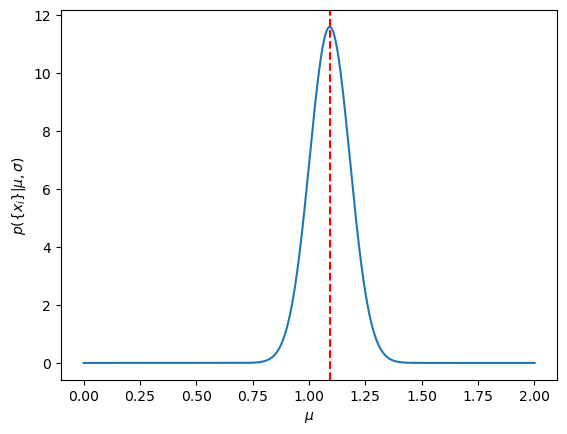

In [138]:
plt.plot(x, like)
plt.axvline(max_x, color="red", linestyle="--")
plt.ylabel(r"$p(\{x_i\}|\mu,\sigma)$")
plt.xlabel(r'$\mu$')

Text(0.5, 0, '$\\mu$')

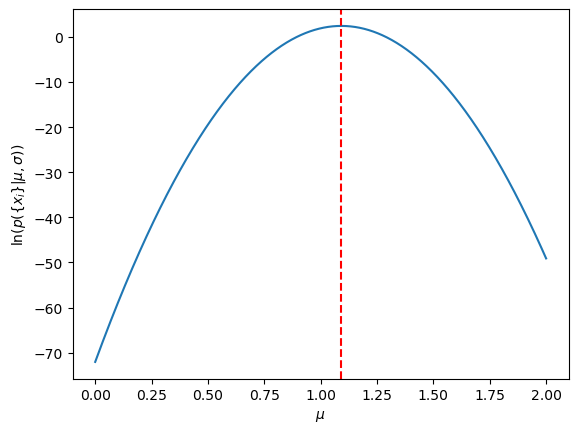

In [140]:
plt.plot(x, ln_like)
plt.axvline(max_x, color="red", linestyle="--")
plt.ylabel(r"$\ln(p(\{x_i\}|\mu,\sigma))$")
plt.xlabel(r'$\mu$')

In [142]:
#print(np.argsort(ln_like))

ln like looks like a parabola

In [145]:
max_ln_like = ln_like[np.argmax(ln_like)]
print("maximum ln likelihood:", max_ln_like)

maximum ln likelihood: 2.449279682234195


### check the fisher matrix error estimates

In [148]:
delta_mu = (x[1]-x[0])
d2_ln_like = np.diff(ln_like, n=2) #to perform second derivative 
fisher = -d2_ln_like/delta_mu**2 #fisher matrix 

In [150]:
#print(fisher)

In [152]:
sigma_mu = 1/np.sqrt(fisher)
#print(sigma_mu) 
sigma_mu_max = sigma_mu[np.argmax(ln_like)]
print(sigma_mu_max)

0.08944271910004176


In [154]:
#from lecture
sigma_mle = 0.2/(N**0.5) 
print(sigma_mle)

0.08944271909999159


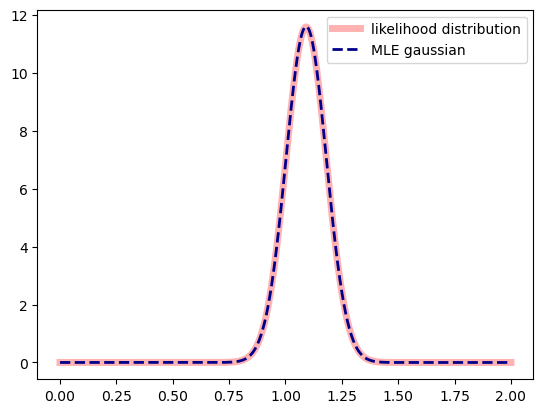

In [156]:
C = 2.6 
#plot a gaussian at the measured mu with this error
pdf_mle = norm.pdf(x, loc=pos_star_mean, scale=sigma_mle)
plt.plot(x, like, color="red", lw=5, label="likelihood distribution", alpha=0.3)
plt.plot(x, pdf_mle*C, color="darkblue", linestyle="--", lw=2, label="MLE gaussian")
plt.legend()

## generalization with sigma normally distributed

In [159]:
N= 5
pos_star =norm.rvs(loc=1, scale=0.2, size=N) 
sigma_star = norm.rvs(loc=0.2, scale=0.05, size=N)
#plt.hist(sigma_star, bins=20) 

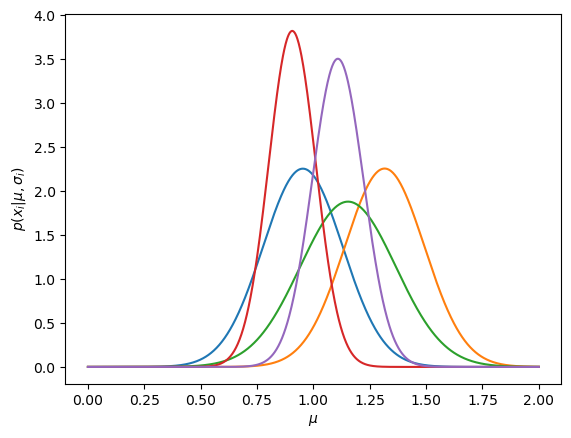

In [161]:
x = np.linspace(0, 2, 1000) #x axis

for pos, sigma in zip(pos_star, sigma_star): 
    pdf_gauss = norm.pdf(x, loc=pos, scale=sigma)
    plt.plot(x, pdf_gauss)
    plt.xlabel(r'$\mu$') 
    plt.ylabel(r'$p(x_i|\mu,\sigma_i)$')

In [163]:
pdf_gauss_tot = []

for pos,sigma in zip(pos_star, sigma_star): 
    pdf_gauss = norm.pdf(x, loc=pos, scale=sigma)
    pdf_gauss_tot.append(pdf_gauss)

#print(pdf_gauss_tot)
like_gen = np.prod(pdf_gauss_tot, axis=0)
ln_like_gen = np.log(like_gen) #log in base e 
#print(like_gen)
#print(len(like_gen))

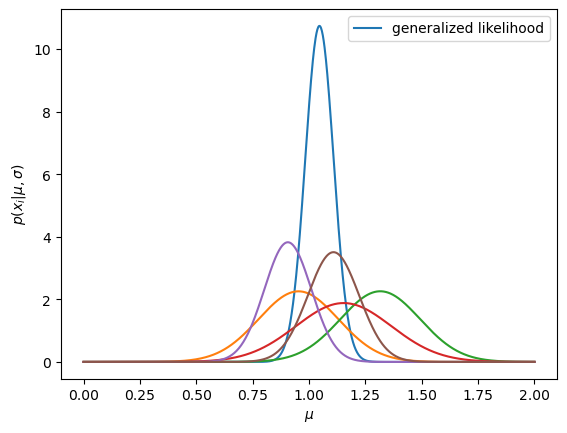

In [165]:
plt.plot(x, like_gen, label="generalized likelihood")
for pos, sigma in zip(pos_star, sigma_star): 
    pdf_gauss = norm.pdf(x, loc=pos, scale=sigma)
    plt.plot(x, pdf_gauss)
    plt.xlabel(r'$\mu$') 
    plt.ylabel(r'$p(x_i|\mu,\sigma)$')

plt.legend()

In [167]:
arg_max_like_gen = np.argmax(like_gen)
print("index for max likelihood:", arg_max_like_gen)

index for max likelihood: 523


In [169]:
max_like_gen = like_gen[arg_max_like_gen]
max_x_gen = x[arg_max_like_gen]
pos_star_mean = np.mean(pos_star)

print("maximum of the likelihood:",max_like_gen)
print("maximum x:", max_x_gen)
print("mean position of star:", pos_star_mean)

maximum of the likelihood: 10.736097235854807
maximum x: 1.047047047047047
mean position of star: 1.0874238498144853


Text(0.5, 0, '$\\mu$')

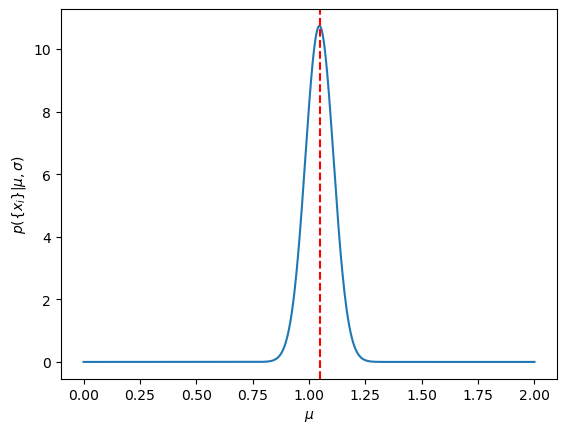

In [171]:
plt.plot(x, like_gen)
plt.axvline(max_x_gen, color="red", linestyle="--")
plt.ylabel(r"$p(\{x_i\}|\mu,\sigma)$")
plt.xlabel(r'$\mu$')

Text(0.5, 0, '$\\mu$')

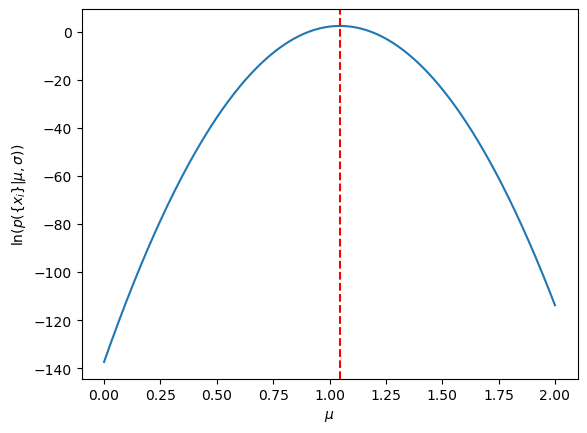

In [173]:
plt.plot(x, ln_like_gen)
plt.axvline(max_x_gen, color="red", linestyle="--")
plt.ylabel(r"$\ln(p(\{x_i\}|\mu,\sigma))$")
plt.xlabel(r'$\mu$')

In [175]:
max_ln_like_gen = ln_like_gen[np.argmax(ln_like_gen)]
print("max ln likelihood:", max_ln_like_gen)

max ln likelihood: 2.3736116371792586


In [177]:
delta_mu = (x[1]-x[0])
d2_ln_like_gen = np.diff(ln_like_gen, n=2)
fisher = -d2_ln_like_gen/(delta_mu**2)

In [179]:
#fisher

In [181]:
sigma_mu = 1/np.sqrt(fisher)
#print(sigma_mu) 
sigma_mu_max = sigma_mu[np.argmax(ln_like)]
print(sigma_mu_max)

0.06257653958222799


In [185]:
#from lecture
sigma_MLE = np.sum(sigma_star**-2)**-0.5
print(sigma_MLE)

0.06257653958225019
